In [5]:
# !pip install spacy
# !python -m spacy download en_core_web_sm
# !pip install plotly
# !pip install scikit-learn
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install nltk

In [6]:
import json
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint

In [7]:
# Load the JSON file (replace with your actual file path)
file_path = r'complaints-2021-05-14_08_16.json'

# Open and read the JSON file
with open(file_path, 'r') as file:
    data = json.load(file)  # Load the JSON directly

# Normalize JSON data into a flat table
df = pd.json_normalize(data)

# Display 10 random samples from the DataFrame
df.sample(3)

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
76751,complaint-public-v2,complaint,2861409,0.0,None,11358,2861409,Closing your account,2018-04-02T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Postal mail,2018-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Company closed your account,N/A
13103,complaint-public-v2,complaint,1191904,0.0,None,14612,1191904,"Application, originator, mortgage broker",2015-01-14T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2015-01-16T12:00:00-05:00,None,Other mortgage,Yes,,None,N/A
74821,complaint-public-v2,complaint,3130721,0.0,Older American,85249,3130721,Getting a credit card,2019-01-22T12:00:00-05:00,AZ,...,Closed with explanation,JPMORGAN CHASE & CO.,Phone,2019-01-23T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Application denied,N/A


In [8]:
# Remove '_source.' from column names
df.columns = df.columns.str.replace(r'^_source\.', '', regex=True)

df.sample(5)

,_index,_type,_id,_score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_what_happened,sub_issue,consumer_consent_provided
2507,complaint-public-v2,complaint,610886,0.0,None,08619,610886,Deposits and withdrawals,2013-11-25T12:00:00-05:00,NJ,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2013-11-27T12:00:00-05:00,None,Checking account,Yes,,None,N/A
1864,complaint-public-v2,complaint,2863284,0.0,None,601XX,2863284,Opening an account,2018-04-03T12:00:00-05:00,IL,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2018-04-03T12:00:00-05:00,None,Checking account,Yes,I am trying to open an account for my adult so...,Unable to open an account,Consent provided
19329,complaint-public-v2,complaint,4063341,0.0,Servicemember,322XX,4063341,Closing an account,2021-01-12T12:00:00-05:00,FL,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2021-01-12T12:00:00-05:00,None,Checking account,Yes,My daughter XXXX XXXX and I XXXX XXXX have acc...,Company closed your account,Consent provided
55706,complaint-public-v2,complaint,3055077,0.0,None,328XX,3055077,Struggling to pay mortgage,2018-10-24T12:00:00-05:00,FL,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2018-10-26T12:00:00-05:00,None,Reverse mortgage,Yes,,None,N/A
77531,complaint-public-v2,complaint,314200,0.0,None,94553,314200,"Loan modification,collection,foreclosure",2013-02-12T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2013-02-13T12:00:00-05:00,None,Other mortgage,Yes,,None,N/A


In [9]:
# Drop NaN values first
df = df.dropna(subset=['complaint_what_happened'])

# Drop rows with empty or whitespace-only values
df = df[df['complaint_what_happened'].str.strip() != '']

In [10]:
df.head()

,_index,_type,_id,_score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_what_happened,sub_issue,consumer_consent_provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Other personal consumer report,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Credit reporting,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Checking account,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided


In [11]:
df.shape

(21072, 22)

In [12]:
df.isnull().sum()

_index                           0
_type                            0
_id                              0
_score                           0
tags                         17256
zip_code                      4645
complaint_id                     0
issue                            0
date_received                    0
state                          143
consumer_disputed                0
product                          0
company_response                 0
company                          0
submitted_via                    0
date_sent_to_company             0
company_public_response      21070
sub_product                   2109
timely                           0
complaint_what_happened          0
sub_issue                     8176
consumer_consent_provided        0
dtype: int64

In [13]:
df['state'].nunique()

60

In [14]:
df['consumer_consent_provided'].value_counts()

consumer_consent_provided
Consent provided    21072
Name: count, dtype: int64

In [15]:
df['company_response'].value_counts()

company_response
Closed with explanation            16189
Closed with monetary relief         3328
Closed with non-monetary relief     1516
Closed                                39
Name: count, dtype: int64

In [16]:
# Define the save path
save_path = r'cleaned_complaints.csv'

# Save the DataFrame as a CSV file
df.to_csv(save_path, index=False)

print("CSV file has been saved successfully.")

CSV file has been saved successfully.


In [17]:
df['consumer_disputed'].value_counts()

consumer_disputed
N/A    14811
No      4609
Yes     1652
Name: count, dtype: int64

In [18]:
df.columns

Index(['_index', '_type', '_id', '_score', 'tags', 'zip_code', 'complaint_id',
       'issue', 'date_received', 'state', 'consumer_disputed', 'product',
       'company_response', 'company', 'submitted_via', 'date_sent_to_company',
       'company_public_response', 'sub_product', 'timely',
       'complaint_what_happened', 'sub_issue', 'consumer_consent_provided'],
      dtype='object')

In [20]:
# pip install textblob

In [21]:
from textblob import TextBlob

# Create a TextBlob object
text = "I love using TextBlob. It's so simple and effective!"
blob = TextBlob(text)

# Get sentiment polarity and subjectivity
print(blob.sentiment)  # Polarity (-1 to 1), Subjectivity (0 to 1)

Sentiment(polarity=0.4166666666666667, subjectivity=0.5857142857142857)


In [22]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bhavinbaldota/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# Download stopwords if you haven't already
#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Initialize the stemmer
stemmer = PorterStemmer()

# Function to clean and stem text
def clean_and_stem_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\n', ' ', text)  # Remove newlines
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)  # Remove email addresses
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[$€£]', ' to ', text)  # Replace currency symbols with 'to'
    text = re.sub(r'\{.*?\}', '', text)  # Remove text inside curly braces like {$1600.00}
    text = re.sub(r'[\{\}\(\)]', ' to ', text)  # Replace parentheses and braces
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and punctuation
    text = re.sub(r'\b(?:' + '|'.join(stop_words) + r')\b', '', text)  # Remove stopwords
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'xxxxxx', '', text)  # Remove occurrences of "xxxxxx"
    text = re.sub(r'xxxx', '', text)  # Remove occurrences of "xx", "xxxx", etc.
    text = re.sub(r'xx', '', text)  # Remove occurrences of "xx" etc.
    
    # Stemming the cleaned text
    text = ' '.join([stemmer.stem(word) for word in text.split()])  # Apply stemming

    return text

# Apply the function to clean and stem the text column
df['complaint_what_happened_stemmed'] = df['complaint_what_happened'].apply(clean_and_stem_text)

# Display the cleaned and stemmed DataFrame
print(df['complaint_what_happened_stemmed'])

1        good morn name appreci could help put stop cha...
2        upgrad card told agent upgrad anniversari date...
10       chase card report howev fraudul applic submit ...
11       tri book ticket came across offer appli toward...
14       grand son give check deposit chase account fun...
                               ...                        
78303    chase card custom well decad offer multipl sol...
78309    wednesday call cha visa credit card provid ask...
78310    familiar pay understand great risk provid cons...
78311    flawless credit yr ive chase credit card chase...
78312    roughli year ago close account jp morgan chase...
Name: complaint_what_happened_stemmed, Length: 21072, dtype: object


In [24]:
from collections import Counter

# Combine all text in the column into a single string
all_text = ' '.join(df['complaint_what_happened_stemmed'])

# Split the text into individual words
words = all_text.split()

# Count the frequency of each word
word_freq = Counter(words)

# Get the 10 most common words
most_common_words = word_freq.most_common(1000)

# Display the most common words
print("Most Repeated Words:\n")
for word, freq in most_common_words:
    print(f"{word}: {freq}")


Most Repeated Words:

chase: 80633
account: 49218
credit: 34185
card: 30538
bank: 30068
call: 26095
payment: 21186
would: 20323
charg: 18251
check: 17889
receiv: 17849
time: 16627
told: 16381
inform: 14241
report: 13920
day: 13263
money: 11961
close: 11594
back: 11461
get: 11063
loan: 11013
ask: 11000
said: 10887
state: 10084
pay: 9969
never: 9948
letter: 9686
use: 9432
made: 9317
contact: 9305
could: 9268
claim: 9215
request: 8970
fee: 8957
transact: 8696
servic: 8671
number: 8655
month: 8573
also: 8542
amount: 8457
year: 8418
sent: 8327
disput: 8222
mortgag: 8215
custom: 8207
provid: 8088
make: 8073
balanc: 7856
phone: 7724
one: 7651
compani: 7643
issu: 7515
need: 7400
fund: 7360
fraud: 7292
due: 7286
sinc: 7106
file: 7097
go: 6881
email: 6851
document: 6765
tri: 6743
open: 6723
paid: 6697
deposit: 6672
even: 6525
date: 6460
help: 6392
purchas: 6272
transfer: 6143
person: 6031
new: 5992
still: 5975
us: 5777
busi: 5748
nt: 5602
interest: 5580
want: 5577
name: 5436
home: 5319
statement

In [26]:
# pip install wordcloud

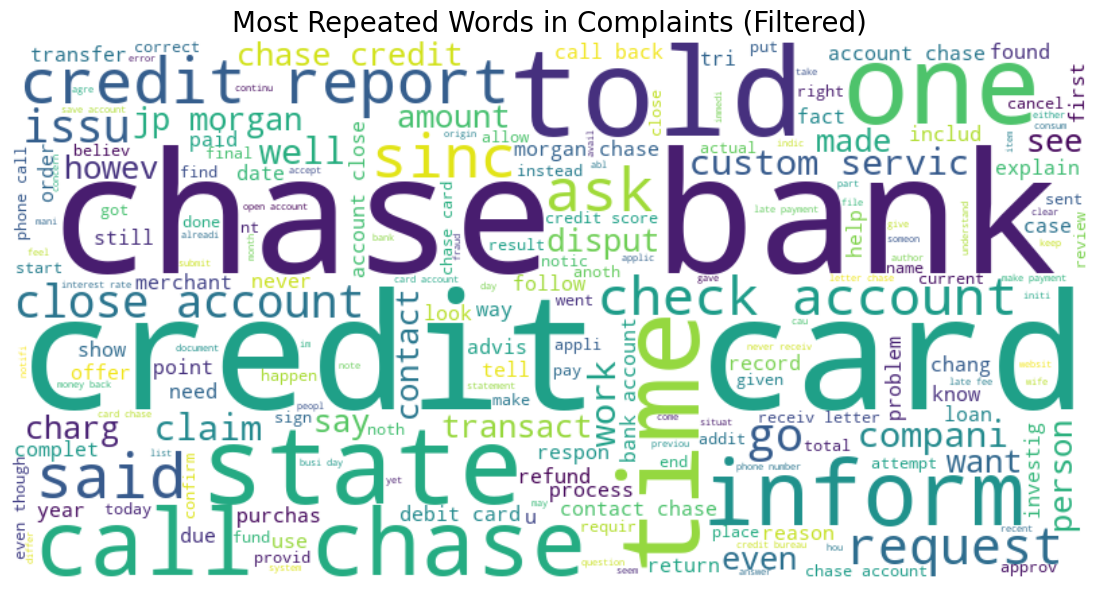

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from the stemmed column into one string
all_text = ' '.join(df['complaint_what_happened_stemmed'])

# Filter out words containing 'xxxx'
filtered_words = ' '.join([word for word in all_text.split() if 'xxxx' not in word])

# Generate a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(filtered_words)

# Plot the WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title("Most Repeated Words in Complaints (Filtered)", fontsize=20)
plt.show()

In [30]:
# import nltk
# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

In [29]:
from textblob import TextBlob

# Function to extract only nouns, excluding those containing 'XXXX'
def extract_nouns(text):
    blob = TextBlob(text)
    nouns = [word for word, tag in blob.tags if tag in ('NN', 'NNS', 'NNP', 'NNPS') and 'XXXX' not in word]
    return ' '.join(nouns)

# Apply the function to create a new column for nouns without 'XXXX'
df['nouns'] = df['complaint_what_happened'].astype(str).apply(extract_nouns)

# Display a sample of the DataFrame
df[['complaint_what_happened', 'nouns']].sample(5)

,complaint_what_happened,nouns
26068,"XXXX XXXX, 2015 both my checking and saving ac...",checking accounts notice Chase bank suspension...
20774,Someone stole my Chase XXXX visa credit card #...,Someone Chase visa credit card week gasoline s...
69438,I had a 0.00 % Promotion balance transfer bala...,% Promotion balance transfer balance XX/XX/201...
29317,JPMorgan chase offers a Credit card for each B...,JPMorgan chase Credit card Branch Military dut...
70523,I can not get into my online banking with Chas...,banking Chase debit card bank account balance ...


In [36]:
#Removing -PRON- from the text corpus
df['Complaint_clean'] = df['nouns'].str.replace('-PRON-', '')

In [37]:
new_df = df[['complaint_what_happened', 'complaint_what_happened_stemmed', 'nouns', 'Complaint_clean']]
new_df.sample(5)

,complaint_what_happened,complaint_what_happened_stemmed,nouns,Complaint_clean
28988,Chase charged my account {$100.00} in overdraf...,chase charg account overdraft fee refund one a...,Chase account overdraft fees agreement Chase a...,Chase account overdraft fees agreement Chase a...
75354,I have been paying on time until XX/XX/XXXX. I...,pay time miss payment due sick call chase wave...,time payment CHASE fee time month payment way ...,time payment CHASE fee time month payment way ...
5656,"On XX/XX/XXXX, while placing an order at Amazo...",place order amazon offer gift card appli amazo...,order Amazon gift card Amazon Reward Visa Card...,order Amazon gift card Amazon Reward Visa Card...
55682,"On XX/XX/XXXX, I searched for tickets on XXXX ...",search ticket game found seller reach suggest ...,tickets game seller price tickets payment h to...,tickets game seller price tickets payment h to...
29363,Chase bank reported a 30 day late payment on m...,chase bank report day late payment credit repo...,Chase bank day payment credit reports home equ...,Chase bank day payment credit reports home equ...


In [38]:
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')

In [39]:
dtm = tfidf.fit_transform(new_df['Complaint_clean'])

In [40]:
from sklearn.decomposition import NMF

In [ ]:
# !pip install gensim

In [41]:
import warnings
warnings.filterwarnings("ignore")
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf
from gensim.models.coherencemodel import CoherenceModel
from operator import itemgetter

# Use Gensim's NMF to get the best num of topics via coherence score
texts = new_df['Complaint_clean']
dataset = [d.split() for d in texts]

# Create a dictionary
# In gensim a dictionary is a mapping between words and their integer id
dictionary = Dictionary(dataset)

# Filter out extremes to limit the number of features
dictionary.filter_extremes(
    no_below=3,
    no_above=0.85,
    keep_n=5000
)

# Create the bag-of-words format (list of (token_id, token_count))
corpus = [dictionary.doc2bow(text) for text in dataset]

# Create a list of the topic numbers we want to try
topic_nums = list(np.arange(5, 10, 1))

# Run the nmf model and calculate the coherence score
# for each number of topics
coherence_scores = []

for num in topic_nums:
    nmf = Nmf(
        corpus=corpus,
        num_topics=num,
        id2word=dictionary,
        chunksize=2000,
        passes=5,
        kappa=.1,
        minimum_probability=0.01,
        w_max_iter=300,
        w_stop_condition=0.0001,
        h_max_iter=100,
        h_stop_condition=0.001,
        eval_every=10,
        normalize=True,
        random_state=42
    )
    
    # Run the coherence model to get the score
    cm = CoherenceModel(
        model=nmf,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence_scores.append(round(cm.get_coherence(), 5))

# Get the number of topics with the highest coherence score
scores = list(zip(topic_nums, coherence_scores))
best_num_topics = sorted(scores, key=itemgetter(1), reverse=True)[0][0]

print(best_num_topics)

5


In [42]:
# Convert text into TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
dtm = tfidf.fit_transform(new_df['Complaint_clean'])

# Initialize and fit the NMF model
nmf_model = NMF(n_components=5, random_state=40)
nmf_model.fit(dtm)

# Print the number of words in vocabulary
print("Number of words in vocabulary:", len(tfidf.get_feature_names_out()))

# Get the top words from a sample component (first topic)
single_topic = nmf_model.components_[0]
top_word_indices = single_topic.argsort()[-10:][::-1]  # Sort in descending order

print("\nTop 10 words in Topic 1:")
for index in top_word_indices:
    print(tfidf.get_feature_names_out()[index])

Number of words in vocabulary: 18333

Top 10 words in Topic 1:
account
bank
chase
check
money
funds
branch
deposit
accounts
checking


In [43]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer


# ✅ Step 3: Get feature names AFTER fitting
feature_names = tfidf.get_feature_names_out()

# ✅ Step 4: Print Top 10 words for each topic
for index, topic in enumerate(nmf_model.components_):
    print(f"\nTop words for Topic #{index + 1}:")
    top_word_indices = topic.argsort()[-10:][::-1]  # Get top 10 words in descending order
    top_words = [feature_names[i] for i in top_word_indices]
    print(", ".join(top_words))



Top words for Topic #1:
account, bank, chase, check, money, funds, branch, deposit, accounts, checking

Top words for Topic #2:
credit, report, inquiry, card, inquiries, score, cards, accounts, account, debt

Top words for Topic #3:
xx, 2020, 2019, 2018, 2017, 18, 2016, 19, 20, payment

Top words for Topic #4:
payment, loan, mortgage, chase, payments, home, modification, time, month, property

Top words for Topic #5:
card, chase, charges, charge, credit, fraud, dispute, fee, merchant, balance


In [44]:
#Creating the best topic for each complaint
topic_results = nmf_model.transform(dtm)
topic_results[0].round(2)          # return array
topic_results[0].argmax()          # argmax() finds the index of the highest value.
topic_results.argmax(axis=1)       # argmax(axis=1) finds the best topic for every complaint.


# Complaint 1 → Topic #2
# Complaint 2 → Topic #4
# Complaint 3 → Topic #1
# Complaint 4 → Topic #0
# Complaint 5 → Topic #3
# … and so on.

array([0, 2, 2, ..., 4, 4, 3])

In [45]:
#Assign the best topic to each of the cmplaints in Topic Column
new_df['Topic'] = topic_results.argmax(axis=1)

In [46]:
new_df.head()

,complaint_what_happened,complaint_what_happened_stemmed,nouns,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morn name appreci could help put stop cha...,morning name stop Chase Bank cardmember servic...,morning name stop Chase Bank cardmember servic...,0
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,upgrad card told agent upgrad anniversari date...,card XX/XX/2018 agent upgrade date agent infor...,card XX/XX/2018 agent upgrade date agent infor...,2
10,Chase Card was reported on XX/XX/2019. However...,chase card report howev fraudul applic submit ...,Chase Card XX/XX/2019 application identity con...,Chase Card XX/XX/2019 application identity con...,2
11,"On XX/XX/2018, while trying to book a XXXX XX...",tri book ticket came across offer appli toward...,XX/XX/2018 book ticket offer ticket rewards ca...,XX/XX/2018 book ticket offer ticket rewards ca...,2
14,my grand son give me check for {$1600.00} i de...,grand son give check deposit chase account fun...,son deposit chase account fund chase bank acco...,son deposit chase account fund chase bank acco...,0


In [47]:
#Print the first 5 Complaint for each of the Topics
df_dc=new_df.groupby('Topic').head(5)
df_dc.sort_values('Topic')

,complaint_what_happened,complaint_what_happened_stemmed,nouns,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morn name appreci could help put stop cha...,morning name stop Chase Bank cardmember servic...,morning name stop Chase Bank cardmember servic...,0
24,mishandling of this account by Chase auto and ...,mishandl account chase auto,mishandling account Chase auto,mishandling account Chase auto,0
17,With out notice J.P. Morgan Chase restricted m...,notic jp morgan chase restrict account debit c...,J.P. Morgan Chase account debit card Tuesday X...,J.P. Morgan Chase account debit card Tuesday X...,0
14,my grand son give me check for {$1600.00} i de...,grand son give check deposit chase account fun...,son deposit chase account fund chase bank acco...,son deposit chase account fund chase bank acco...,0
27,I opened an account with chase bank on XXXX an...,open account chase bank use code bonu call fol...,account bank code bonus terms everything accou...,account bank code bonus terms everything accou...,0
15,Can you please remove inquiry,pleas remov inquiri,inquiry,inquiry,1
64,Chase is marketing credit cards to those of us...,chase market credit card us good credit like g...,Chase credit cards credit style marketing IF S...,Chase credit cards credit style marketing IF S...,1
23,I have a Chase credit card which is incorrectl...,chase credit card incorrectli report data cred...,Chase credit card data credit report company i...,Chase credit card data credit report company i...,1
82,I recently called to ask Chase bank why they r...,recent call ask chase bank report credit burea...,Chase bank credit Bureau days payment info XX/...,Chase bank credit Bureau days payment info XX/...,1
26,I have reached out to XXXX several times in at...,reach sever time attempt fraudul inquiri remov...,times attempt inquiry creditor inquiry report ...,times attempt inquiry creditor inquiry report ...,1


In [48]:
#Create the dictionary of Topic names and Topics 
Topic_names = {0:"Bank Account services",1:"Credit card or prepaid card", 2:"Others", 3:"Mortgage/Loan", 4:"Theft/Dispute Reporting"}

In [49]:
#Replace Topics with Topic Names
new_df['Topic'] = new_df['Topic'].map(Topic_names)

In [50]:
#Print the first 5 Complaint for each of the Topics
df_dc=new_df.groupby('Topic').head(5)
df_dc.sort_values('Topic')

,complaint_what_happened,complaint_what_happened_stemmed,nouns,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morn name appreci could help put stop cha...,morning name stop Chase Bank cardmember servic...,morning name stop Chase Bank cardmember servic...,Bank Account services
24,mishandling of this account by Chase auto and ...,mishandl account chase auto,mishandling account Chase auto,mishandling account Chase auto,Bank Account services
17,With out notice J.P. Morgan Chase restricted m...,notic jp morgan chase restrict account debit c...,J.P. Morgan Chase account debit card Tuesday X...,J.P. Morgan Chase account debit card Tuesday X...,Bank Account services
14,my grand son give me check for {$1600.00} i de...,grand son give check deposit chase account fun...,son deposit chase account fund chase bank acco...,son deposit chase account fund chase bank acco...,Bank Account services
27,I opened an account with chase bank on XXXX an...,open account chase bank use code bonu call fol...,account bank code bonus terms everything accou...,account bank code bonus terms everything accou...,Bank Account services
15,Can you please remove inquiry,pleas remov inquiri,inquiry,inquiry,Credit card or prepaid card
64,Chase is marketing credit cards to those of us...,chase market credit card us good credit like g...,Chase credit cards credit style marketing IF S...,Chase credit cards credit style marketing IF S...,Credit card or prepaid card
23,I have a Chase credit card which is incorrectl...,chase credit card incorrectli report data cred...,Chase credit card data credit report company i...,Chase credit card data credit report company i...,Credit card or prepaid card
26,I have reached out to XXXX several times in at...,reach sever time attempt fraudul inquiri remov...,times attempt inquiry creditor inquiry report ...,times attempt inquiry creditor inquiry report ...,Credit card or prepaid card
82,I recently called to ask Chase bank why they r...,recent call ask chase bank report credit burea...,Chase bank credit Bureau days payment info XX/...,Chase bank credit Bureau days payment info XX/...,Credit card or prepaid card


In [51]:
training_data=new_df[["complaint_what_happened","Topic"]]

In [52]:
training_data

,complaint_what_happened,Topic
1,Good morning my name is XXXX XXXX and I apprec...,Bank Account services
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Others
10,Chase Card was reported on XX/XX/2019. However...,Others
11,"On XX/XX/2018, while trying to book a XXXX XX...",Others
14,my grand son give me check for {$1600.00} i de...,Bank Account services
...,...,...
78303,After being a Chase Card customer for well ove...,Credit card or prepaid card
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",Theft/Dispute Reporting
78310,I am not familiar with XXXX pay and did not un...,Theft/Dispute Reporting
78311,I have had flawless credit for 30 yrs. I've ha...,Theft/Dispute Reporting


In [53]:
import pickle
from sklearn.feature_extraction.text import CountVectorizer


#GET VECTOR COUNT
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(training_data.complaint_what_happened)

#SAVE WORD VECTOR
pickle.dump(count_vect.vocabulary_, open("count_vector.pkl","wb"))

In [54]:
from sklearn.feature_extraction.text import TfidfTransformer

#TRANSFORM WORD VECTOR TO TF IDF
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

#SAVE TF-IDF
pickle.dump(tfidf_transformer, open("tfidf.pkl","wb"))

In [55]:
# Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_train_tfidf, training_data.Topic, test_size=0.25, random_state=42)
clf = MultinomialNB().fit(X_train, y_train)

#SAVE MODEL
pickle.dump(clf, open("nb_model.pkl", "wb"))

In [56]:
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

# Define the target names
target_names = ["Bank Account services", "Credit card or prepaid card", "Others", "Theft/Dispute Reporting", "Mortgage/Loan"]

# New document for prediction
docs_new = "I can not get from chase who services my mortgage, who owns it and who has original loan docs"
docs_new = [docs_new]  # Convert to a list

# Load pre-trained models and transformers
loaded_vec = CountVectorizer(vocabulary=pickle.load(open("count_vector.pkl", "rb")))
loaded_tfidf = pickle.load(open("tfidf.pkl", "rb"))
loaded_model = pickle.load(open("nb_model.pkl", "rb"))

# Transform the input text
X_new_counts = loaded_vec.transform(docs_new)
X_new_tfidf = loaded_tfidf.transform(X_new_counts)

# Predict the category
predicted = loaded_model.predict(X_new_tfidf)

# Print the result
print(predicted[0])  # Directly print the category name

Mortgage/Loan
